In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Global style
plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Color palette
COLORS = {
    'primary'  : '#2C3E50',
    'profit'   : '#27AE60',
    'revenue'  : '#2980B9',
    'cost'     : '#E74C3C',
    'warning'  : '#F39C12',
    'highlight': '#8E44AD'
}

In [3]:
df = pd.read_csv('../data/nassau_candy_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f"Data loaded: {df.shape[0]} rows")

Data loaded: 6013 rows


In [4]:
total_revenue = df['Sales'].sum()
total_cost    = df['Cost'].sum()
total_profit  = df['Gross Profit'].sum()
total_units   = df['Units'].sum()
total_orders  = df['Order ID'].nunique()
avg_margin    = (total_profit / total_revenue) * 100

print("BUSINESS SUMMARY")
print(f"  Total Revenue : ${total_revenue:,.2f}")
print(f"  Total Cost    : ${total_cost:,.2f}")
print(f"  Total Profit  : ${total_profit:,.2f}")
print(f"  Avg Margin    : {avg_margin:.2f}%")
print(f"  Total Units   : {total_units:,}")
print(f"  Total Orders  : {total_orders:,}")

BUSINESS SUMMARY
  Total Revenue : $83,827.43
  Total Cost    : $28,536.06
  Total Profit  : $55,291.37
  Avg Margin    : 65.96%
  Total Units   : 22,755
  Total Orders  : 5,067


### Chart 1: Revenue, Cost, Profit Summary Bar

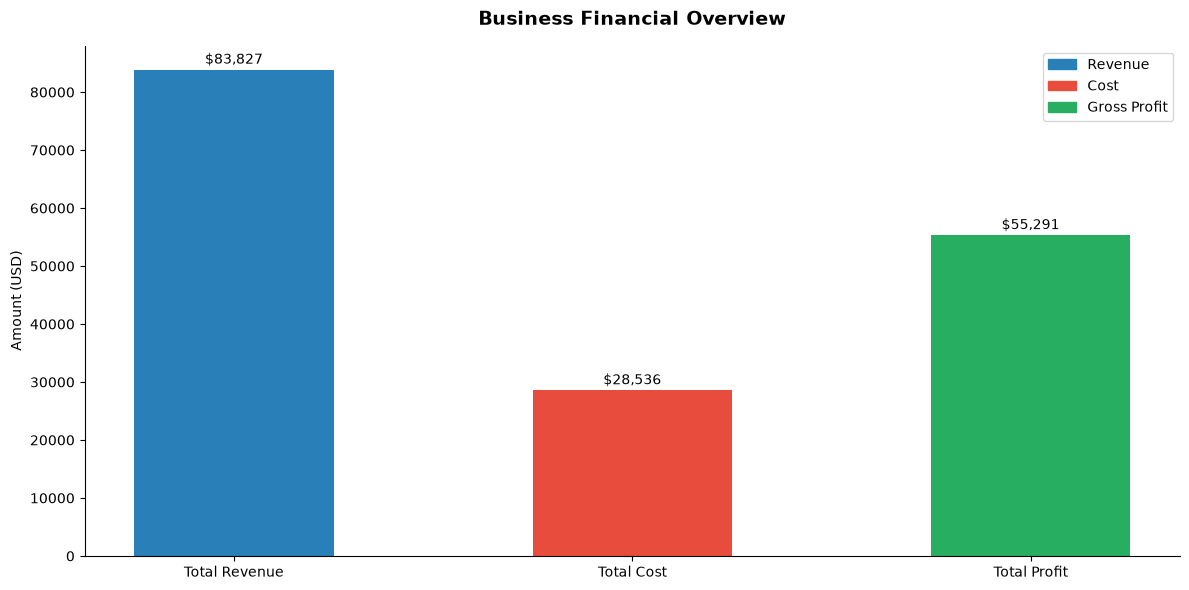

Chart 1 saved


In [5]:
labels = ['Total Revenue', 'Total Cost', 'Total Profit']
values = [total_revenue, total_cost, total_profit]
colors = [COLORS['revenue'], COLORS['cost'], COLORS['profit']]

fig, ax = plt.subplots()

bars = ax.bar(labels, values, color=colors, width=0.5)

ax.set_title('Business Financial Overview', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xlabel('')

# Value labels on top of bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"${bar.get_height():,.0f}",
        ha='center', va='bottom', fontsize=10
    )

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=COLORS['revenue'], label='Revenue'),
    plt.Rectangle((0,0),1,1, color=COLORS['cost'],    label='Cost'),
    plt.Rectangle((0,0),1,1, color=COLORS['profit'],  label='Gross Profit')
], loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/charts/01_business_financial_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

### Chart 2: Revenue vs Profit by Division

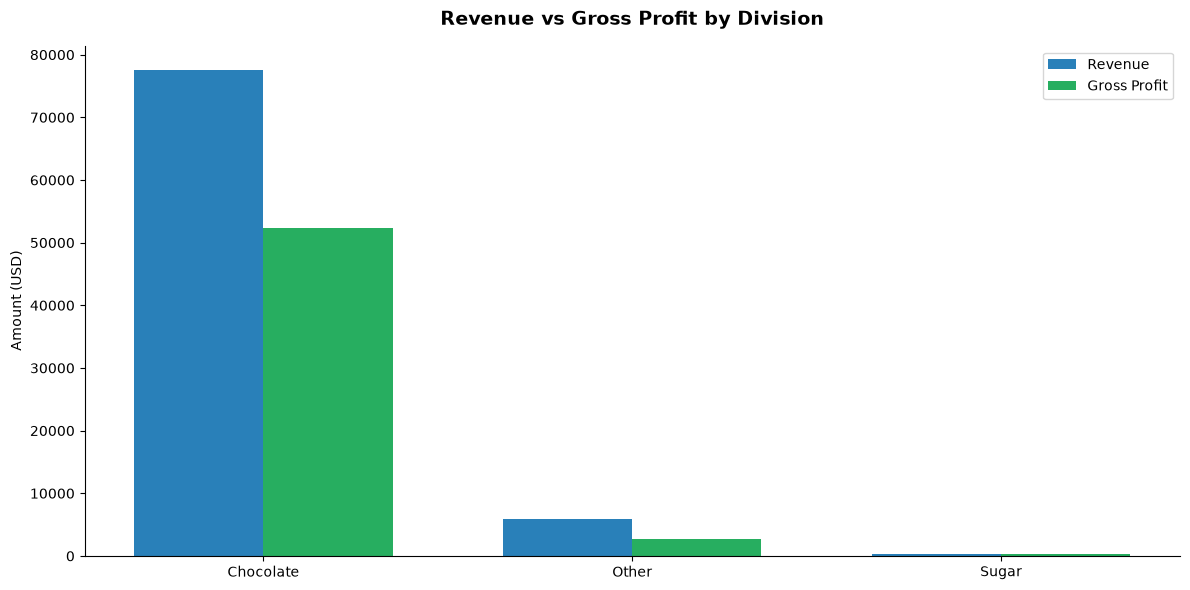

Chart 2 saved


In [6]:
division_data = df.groupby('Division').agg(
    Revenue = ('Sales', 'sum'),
    Profit  = ('Gross Profit', 'sum')
).reset_index().sort_values('Revenue', ascending=False)

x      = np.arange(len(division_data))
width  = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, division_data['Revenue'], width, 
       color=COLORS['revenue'], label='Revenue')
ax.bar(x + width/2, division_data['Profit'],  width, 
       color=COLORS['profit'],  label='Gross Profit')

ax.set_title('Revenue vs Gross Profit by Division', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(division_data['Division'])
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/charts/02_division_revenue_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

### Prepare Monthly Data

In [7]:
df['Month']      = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')
df['Quarter']    = df['Order Date'].dt.quarter

monthly = df.groupby(['Month', 'Month_Name']).agg(
    Revenue = ('Sales', 'sum'),
    Profit  = ('Gross Profit', 'sum')
).reset_index().sort_values('Month')

print(monthly[['Month_Name', 'Revenue', 'Profit']])

   Month_Name   Revenue   Profit
0         Jan   3489.10  2328.81
1         Feb   2553.65  1677.55
2         Mar   5423.24  3588.38
3         Apr   4922.44  3266.10
4         May   6555.68  4329.10
5         Jun   6214.93  4123.89
6         Jul   6057.67  3983.05
7         Aug   5740.10  3795.40
8         Sep  11457.60  7498.83
9         Oct   7345.89  4833.65
10        Nov  11728.86  7750.66
11        Dec  12338.27  8115.95


### Chart 3: Monthly Revenue & Profit Trend

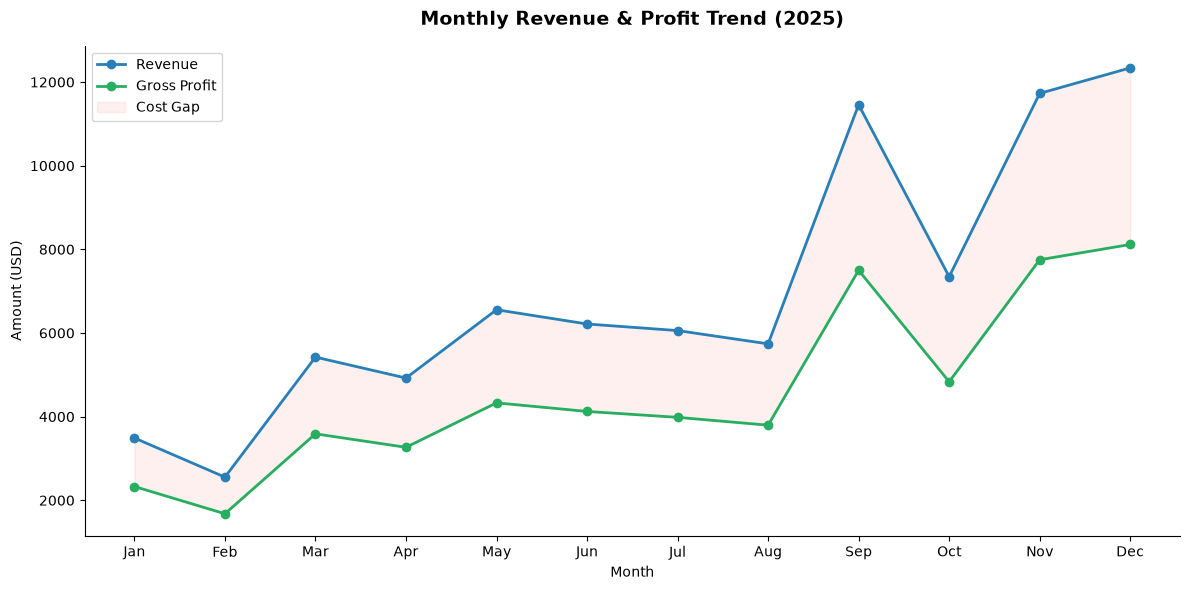

Chart 3 saved


In [8]:
fig, ax = plt.subplots()

ax.plot(monthly['Month_Name'], monthly['Revenue'],
        color=COLORS['revenue'], marker='o', linewidth=2, label='Revenue')

ax.plot(monthly['Month_Name'], monthly['Profit'],
        color=COLORS['profit'], marker='o', linewidth=2, label='Gross Profit')

ax.fill_between(monthly['Month_Name'], monthly['Revenue'], monthly['Profit'],
                alpha=0.08, color=COLORS['cost'], label='Cost Gap')

ax.set_title('Monthly Revenue & Profit Trend (2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xlabel('Month')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/charts/03_monthly_revenue_profit_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

### Prepare Quarterly Data

In [9]:
quarterly = df.groupby('Quarter').agg(
    Revenue = ('Sales', 'sum'),
    Profit  = ('Gross Profit', 'sum')
).reset_index()

quarterly['Quarter_Label'] = 'Q' + quarterly['Quarter'].astype(str)

print(quarterly[['Quarter_Label', 'Revenue', 'Profit']])

  Quarter_Label   Revenue    Profit
0            Q1  11465.99   7594.74
1            Q2  17693.05  11719.09
2            Q3  23255.37  15277.28
3            Q4  31413.02  20700.26


### Chart 4: Quarterly Revenue Growth

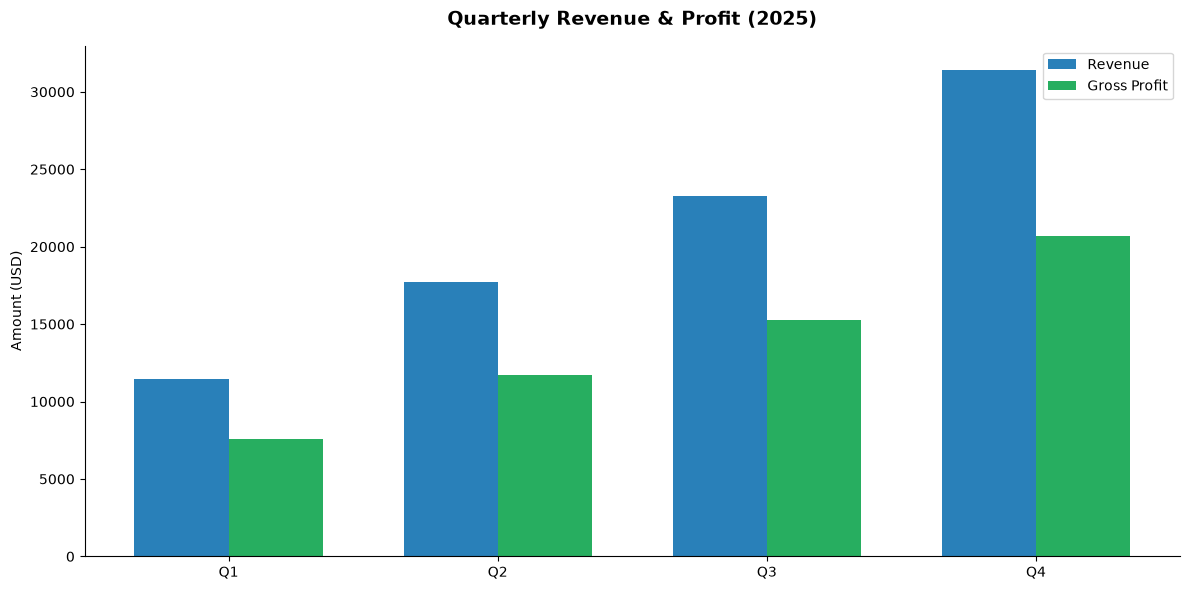

Chart 4 saved


In [10]:
x     = np.arange(len(quarterly))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, quarterly['Revenue'], width,
       color=COLORS['revenue'], label='Revenue')
ax.bar(x + width/2, quarterly['Profit'],  width,
       color=COLORS['profit'],  label='Gross Profit')

ax.set_title('Quarterly Revenue & Profit (2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(quarterly['Quarter_Label'])
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/charts/04_quarterly_revenue_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")